# nan Error analysis

In [18]:
import import_ipynb
import L_layer_model
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

## 1. Troubleshooting: Why did 'nan' occur?

In [108]:
X_train = L_layer_model.X[:, 0].reshape(784, 1)
y_train = L_layer_model.y_one_hot[:, 0].reshape(10, 1)
node_num_list = [784, 500, 100, 10]
parameters = L_layer_model.initialize_weight(node_num_list)
y_hat, cache = L_layer_model.forward_propagation(X_train, parameters)
print(cache['Z3'])

[[-1937.03488687]
 [ -613.48461589]
 [-1602.56377715]
 [ 1489.6705007 ]
 [  513.93209477]
 [  251.12093126]
 [  977.28037563]
 [  445.08319102]
 [ 1217.38987224]
 [ -158.19617999]]


In [109]:
#softmax
Z3 = cache['Z3']
print(cp.exp(Z3))
print('sum:', sum(cp.exp(Z3)))
print(y_hat)

[[0.00000000e+000]
 [3.68991692e-267]
 [0.00000000e+000]
 [            inf]
 [1.57714939e+223]
 [1.14930352e+109]
 [            inf]
 [1.98232038e+193]
 [            inf]
 [1.97820808e-069]]
sum: [inf]
[[ 0.]
 [ 0.]
 [ 0.]
 [nan]
 [ 0.]
 [ 0.]
 [nan]
 [ 0.]
 [nan]
 [ 0.]]


The reason why nan was made was because of inf / inf

## 2. Troubleshooting: Why did 'inf' occur?

In [114]:
print(f'mean: {cp.mean(cache['Z3'])}, var: {cp.var(cache['Z3'])}')

mean: 58.319750572559926, var: 1186921.2486380653


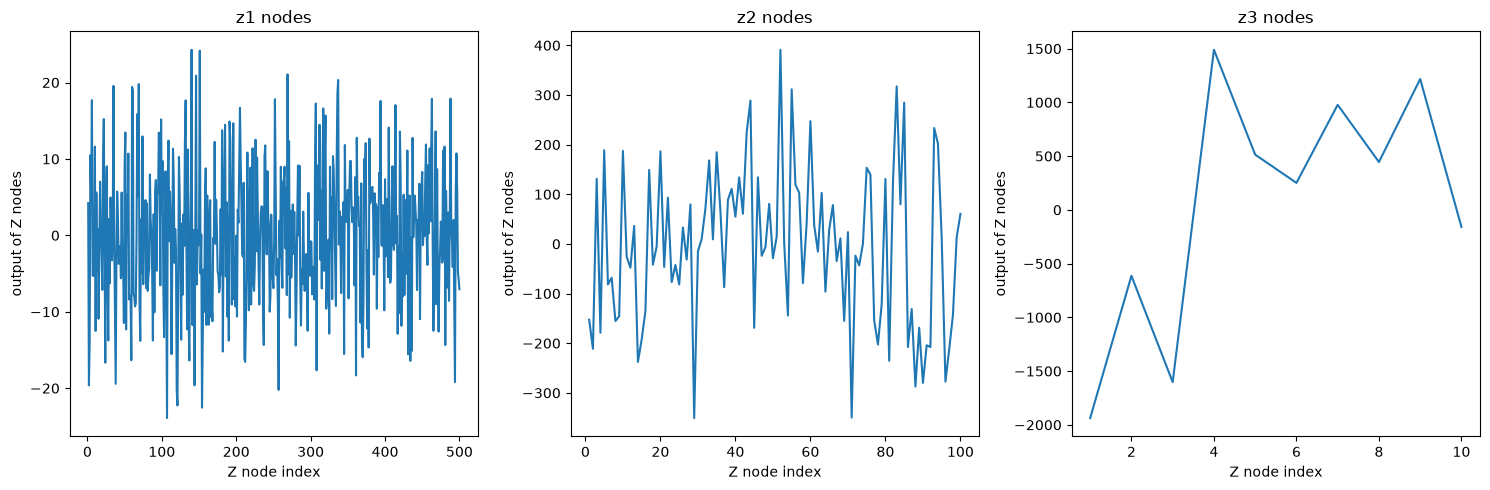

In [110]:
z_list = [np.arange(1, 501), np.arange(1, 101), np.arange(1, 11)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.plot(z_list[i], cache[f'Z{i+1}'].get())
    ax.set_title(f'z{i+1} nodes')
    ax.set_xlabel('Z node index')
    ax.set_ylabel('output of Z nodes')
plt.tight_layout()
plt.show()

The reason why nan was made was because of inf / inf

## 3 Solution (scaling down weights)

We can reduce variance with scaleing down the weights

In [133]:
node_num_list = [784, 500, 100, 10]
parameters = L_layer_model.initialize_weight(node_num_list)
#before scaling down
print('before scaling down')
for i in range(1, 4):
    print(f'mean of W{i}: {cp.mean(parameters[f'W{i}'])}')
    print(f'variance of W{i}: {cp.var(parameters[f'W{i}'])}')
    print('')

print('after scaling down')
for i in range(1, 4):
    parameters[f'W{i}'] *= 0.1
    print(f'mean of W{i}: {cp.mean(parameters[f'W{i}'])}')
    print(f'variance of W{i}: {cp.var(parameters[f'W{i}'])}')
    print('')

before scaling down
mean of W1: 0.002017482003653081
variance of W1: 1.0011964346318487

mean of W2: -0.0015148875101101294
variance of W2: 1.0060971464828425

mean of W3: 0.04857347265072517
variance of W3: 0.9896199659557163

after scaling down
mean of W1: 0.00020174820036530816
variance of W1: 0.01001196434631849

mean of W2: -0.00015148875101101295
variance of W2: 0.010060971464828428

mean of W3: 0.004857347265072516
variance of W3: 0.009896199659557165

